#Group 153

#Selected application domain: Medical Image Diagnosis


| SL.NO | BITS ID      | NAME                      | CONTRIBUTION |
|-------|-------------|---------------------------|--------------|
| 1     | 2024AA05731 | Suraj Anand               | 25%          |
| 2     | 2024AA05733 | Bollam Manindra           | 25%          |
| 3     | 2024AA05732 | Ashvini Satish Bhosale    | 25%          |
| 4     | 2024AA05735 | Nikhil Yadav              | 25%          |



**Journal title:** A review of convolutional neural network based methods for medical image classification

**Authors:** Chao Chen, Nor Ashidi Mat Isa, Xin Liu

**Journal Name:** Computers in Biology and Medicine (Elsevier)

**Link:** https://www.sciencedirect.com/science/article/abs/pii/S0010482524015920

**Dataset Url:** https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

**Year:** 2025

# Import the required libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import os
import zipfile
from pathlib import Path
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("All required libraries imported successfully!")

TensorFlow version: 2.19.0
Keras version: 3.10.0
All required libraries imported successfully!


# Data Acquisition

In [2]:
# Data Acquisition
# Dataset URL and Information
print("\n=== DATASET INFORMATION ===")
print("Dataset: Chest X-Ray Images (Pneumonia Detection)")
print("Source: Google Drive")
print("URL: https://drive.google.com/file/d/1QtCvVb-nqKdYFoAsHfQlOwDE366E38cb/view?usp=sharing")
print("Classes: NORMAL, PNEUMONIA")
print("Total Images: 5,863 X-ray images")
print("Medical Application: Pneumonia detection from chest radiographs")

# Download and setup dataset from Google Drive if not already present
import gdown
import os

# Define dataset directory and zip file path
dataset_dir = "chest_xray"
zip_file = "chest-xray-pneumonia.zip"
file_id = "1QtCvVb-nqKdYFoAsHfQlOwDE366E38cb"
url = f"https://drive.google.com/uc?id={file_id}"

# Check if dataset directory exists
if os.path.exists(dataset_dir):
    print(f"\nDataset found in '{dataset_dir}'. Skipping download and extraction.")
else:
    print("\nDataset not found. Downloading from Google Drive...")
    gdown.download(url, zip_file, quiet=False)

    # Unzip the dataset
    print("\nExtracting dataset...")
    !unzip -q {zip_file}
    # Clean up zip file to save space
    !rm {zip_file}

# Display dataset structure
print("\nDataset structure:")
for root, dirs, files in os.walk(dataset_dir):
    level = root.replace(dataset_dir, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:
        print(f'{subindent}{file}')
    if len(files) > 3:
        print(f'{subindent}... and {len(files)-3} more files')



=== DATASET INFORMATION ===
Dataset: Chest X-Ray Images (Pneumonia Detection)
Source: Google Drive
URL: https://drive.google.com/file/d/1QtCvVb-nqKdYFoAsHfQlOwDE366E38cb/view?usp=sharing
Classes: NORMAL, PNEUMONIA
Total Images: 5,863 X-ray images
Medical Application: Pneumonia detection from chest radiographs

Dataset not found. Downloading from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1QtCvVb-nqKdYFoAsHfQlOwDE366E38cb
From (redirected): https://drive.google.com/uc?id=1QtCvVb-nqKdYFoAsHfQlOwDE366E38cb&confirm=t&uuid=6b36904f-9708-4436-b521-58a1559b1c37
To: /content/chest-xray-pneumonia.zip
100%|██████████| 2.46G/2.46G [00:37<00:00, 66.5MB/s]



Extracting dataset...

Dataset structure:
chest_xray/
  test/
    PNEUMONIA/
      person114_bacteria_546.jpeg
      person127_bacteria_603.jpeg
      person133_bacteria_633.jpeg
      ... and 387 more files
    NORMAL/
      NORMAL2-IM-0301-0001.jpeg
      NORMAL2-IM-0380-0001.jpeg
      NORMAL2-IM-0282-0001.jpeg
      ... and 231 more files
  __MACOSX/
    ._chest_xray
    chest_xray/
      ._.DS_Store
      ._test
      ._train
      test/
        ._.DS_Store
        ._PNEUMONIA
        ._NORMAL
        PNEUMONIA/
          ._person92_bacteria_450.jpeg
          ._person1633_virus_2829.jpeg
          ._person83_bacteria_410.jpeg
          ... and 387 more files
        NORMAL/
          ._NORMAL2-IM-0376-0001.jpeg
          ._NORMAL2-IM-0289-0001.jpeg
          ._IM-0087-0001.jpeg
          ... and 231 more files
      train/
        ._.DS_Store
        ._PNEUMONIA
        ._NORMAL
        PNEUMONIA/
          ._person457_bacteria_1949.jpeg
          ._person423_bacteria_1856.jpeg


# Data Preparation

In [3]:
# Image preprocessing parameters based on Chen et al. methodology
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16

# Dataset paths
train_dir = f'{dataset_dir}/train'
test_dir = f'{dataset_dir}/test'
val_dir = f'{dataset_dir}/val'

# Count images in each dataset split
def count_dataset_images(directory):
    """Count valid image files in each class of the dataset"""
    try:
        classes = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]
        if not classes:
            print(f"  No valid class directories found in {directory}")
            return
        for class_name in classes:
            class_path = os.path.join(directory, class_name)
            # Filter for common image file extensions
            valid_extensions = ('.jpg', '.jpeg', '.png')
            image_files = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
            count = len(image_files)
            print(f"  {class_name}: {count} images")
    except FileNotFoundError:
        print(f"  Directory {directory} not found")
    except Exception as e:
        print(f"  Error processing {directory}: {str(e)}")

print("Dataset distribution:")
print("Training set:")
count_dataset_images(train_dir)
print("Validation set:")
count_dataset_images(val_dir)
print("Test set:")
count_dataset_images(test_dir)

# Data augmentation for training set (following CNN review paper recommendations)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

# Only normalization for validation and test sets
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\nData generators created:")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"Class indices: {train_generator.class_indices}")

Dataset distribution:
Training set:
  PNEUMONIA: 3875 images
  NORMAL: 1341 images
Validation set:
  PNEUMONIA: 8 images
  NORMAL: 8 images
Test set:
  PNEUMONIA: 390 images
  NORMAL: 234 images
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Data generators created:
Training samples: 5216
Validation samples: 16
Test samples: 624
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


## Split the data into training set and testing set

In [4]:
# Dataset is pre-split, display split information
total_images = train_generator.samples + validation_generator.samples + test_generator.samples
train_percent = (train_generator.samples / total_images) * 100
val_percent = (validation_generator.samples / total_images) * 100
test_percent = (test_generator.samples / total_images) * 100

print(f"\nDataset split percentages:")
print(f"Training: {train_percent:.1f}% ({train_generator.samples} images)")
print(f"Validation: {val_percent:.1f}% ({validation_generator.samples} images)")
print(f"Testing: {test_percent:.1f}% ({test_generator.samples} images)")

## Identify the target variables
##---------Type the code below this line------------------##

print(f"\nTarget Variable Information:")
print(f"Problem Type: Binary Medical Image Classification")
print(f"Target: Pneumonia Detection in Chest X-rays")
print(f"Classes: {list(train_generator.class_indices.keys())}")
print(f"Class encoding: {train_generator.class_indices}")
print(f"Output: 0 = NORMAL, 1 = PNEUMONIA")


Dataset split percentages:
Training: 89.1% (5216 images)
Validation: 0.3% (16 images)
Testing: 10.7% (624 images)

Target Variable Information:
Problem Type: Binary Medical Image Classification
Target: Pneumonia Detection in Chest X-rays
Classes: ['NORMAL', 'PNEUMONIA']
Class encoding: {'NORMAL': 0, 'PNEUMONIA': 1}
Output: 0 = NORMAL, 1 = PNEUMONIA


# Deep Neural Network Architecture

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,439,393 (5.49 MB)

 Trainable params: 1,437,409 (5.48 MB)

 Non-trainable params: 1,984 (7.75 KB)

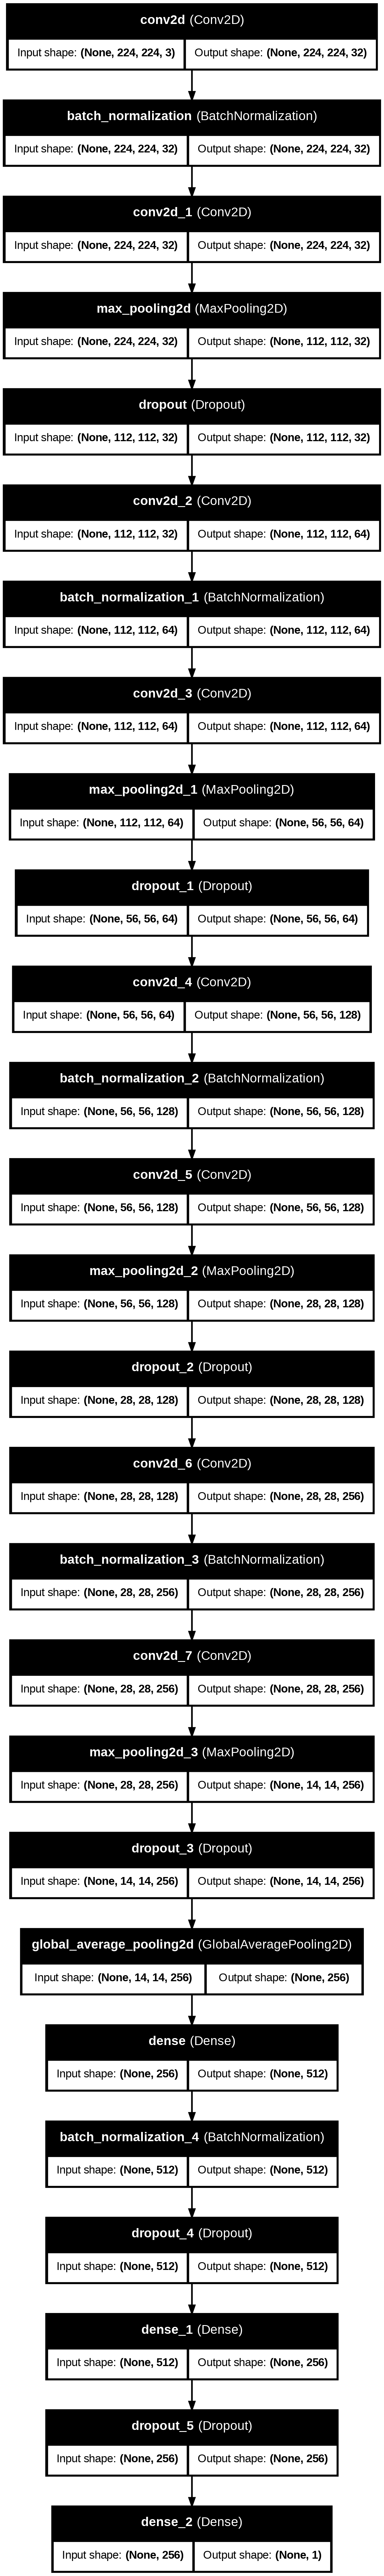

In [5]:

def create_medical_cnn_model():
    """
    CNN architecture based on Chen et al. review paper methodology
    Optimized for medical image classification tasks
    """
    model = Sequential([
        # First Convolutional Block - Feature extraction at high resolution
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Second Convolutional Block - Intermediate feature learning
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Third Convolutional Block - Complex pattern recognition
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Fourth Convolutional Block - High-level feature extraction
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Global Average Pooling - Reduces overfitting compared to flatten
        GlobalAveragePooling2D(),

        # Dense layers for classification
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary classification output
    ])

    return model

# Create and compile the model
model = create_medical_cnn_model()

# Display model architecture
model.summary()

# Visualize model architecture
tf.keras.utils.plot_model(
    model,
    to_file='medical_cnn_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB'
)

# DNN Report

In [6]:
# Model architecture analysis
total_layers = len(model.layers)
conv_layers = len([layer for layer in model.layers if isinstance(layer, Conv2D)])
dense_layers = len([layer for layer in model.layers if isinstance(layer, Dense)])

print(f"\n=== CNN ARCHITECTURE REPORT ===")
print(f"Based on: Chen et al. CNN review methodology")
print(f"Total layers: {total_layers}")
print(f"Convolutional layers: {conv_layers}")
print(f"Dense layers: {dense_layers}")

print(f"\nConvolutional layer filter sizes:")
for i, layer in enumerate(model.layers):
    if isinstance(layer, Conv2D):
        print(f"  Conv2D_{i}: {layer.filters} filters, kernel size: {layer.kernel_size}")

print(f"\nDense layer units:")
for i, layer in enumerate(model.layers):
    if isinstance(layer, Dense):
        print(f"  Dense_{i}: {layer.units} units")

# Parameter count analysis
total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"\n=== PARAMETER ANALYSIS ===")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")


=== CNN ARCHITECTURE REPORT ===
Based on: Chen et al. CNN review methodology
Total layers: 27
Convolutional layers: 8
Dense layers: 3

Convolutional layer filter sizes:
  Conv2D_0: 32 filters, kernel size: (3, 3)
  Conv2D_2: 32 filters, kernel size: (3, 3)
  Conv2D_5: 64 filters, kernel size: (3, 3)
  Conv2D_7: 64 filters, kernel size: (3, 3)
  Conv2D_10: 128 filters, kernel size: (3, 3)
  Conv2D_12: 128 filters, kernel size: (3, 3)
  Conv2D_15: 256 filters, kernel size: (3, 3)
  Conv2D_17: 256 filters, kernel size: (3, 3)

Dense layer units:
  Dense_21: 512 units
  Dense_24: 256 units
  Dense_26: 1 units

=== PARAMETER ANALYSIS ===
Total parameters: 1,439,393
Trainable parameters: 1,437,409
Non-trainable parameters: 1,984


 # Training the model

In [7]:
# Configure training parameters based on Chen et al. recommendations
model.compile(
    optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

# Training callbacks for optimal performance
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_medical_cnn_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=8,
        min_lr=1e-7,
        verbose=1
    )
]

# Training parameters
EPOCHS = 5

print(f"Starting CNN training for medical image classification...")
print(f"Architecture: {conv_layers} Conv2D + {dense_layers} Dense layers")
print(f"Total parameters: {total_params:,}")
print(f"Training samples: {train_generator.samples}")

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("CNN training completed successfully!")

Starting CNN training for medical image classification...
Architecture: 8 Conv2D + 3 Dense layers
Total parameters: 1,439,393
Training samples: 5216
Epoch 1/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.7855 - loss: 0.4805 - precision: 0.8540 - recall: 0.8574
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_medical_cnn_model.h5


326/326 ━━━━━━━━━━━━━━━━━━━━ 130s 333ms/step - accuracy: 0.7856 - loss: 0.4802 - precision: 0.8541 - recall: 0.8575 - val_accuracy: 0.5000 - val_loss: 1.3500 - val_precision: 0.5000 - val_recall: 0.3750 - learning_rate: 0.0010
Epoch 2/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.8939 - loss: 0.2677 - precision: 0.9371 - recall: 0.9170
Epoch 2: val_accuracy improved from 0.50000 to 0.75000, saving model to best_medical_cnn_model.h5


326/326 ━━━━━━━━━━━━━━━━━━━━ 121s 320ms/step - accuracy: 0.8939 - loss: 0.2677 - precision: 0.9371 - recall: 0.9170 - val_accuracy: 0.7500 - val_loss: 0.6038 - val_precision: 0.6667 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.9080 - loss: 0.2431 - precision: 0.9471 - recall: 0.9271
Epoch 3: val_accuracy did not improve from 0.75000
326/326 ━━━━━━━━━━━━━━━━━━━━ 140s 315ms/step - accuracy: 0.9080 - loss: 0.2431 - precision: 0.9471 - recall: 0.9271 - val_accuracy: 0.5000 - val_loss: 15.3632 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9122 - loss: 0.2116 - precision: 0.9469 - recall: 0.9341
Epoch 4: val_accuracy did not improve from 0.75000
326/326 ━━━━━━━━━━━━━━━━━━━━ 142s 316ms/step - accuracy: 0.9122 - loss: 0.2117 - precision: 0.9468 - recall: 0.9341 - val_accuracy: 0.5000 - val_loss: 9.4570 - val_precision: 0.5000 - val_recall:

# Test the model

In [8]:

# Load best model weights
model.load_weights('best_medical_cnn_model.h5')

print("Evaluating trained CNN on test dataset...")

# Evaluate model performance on test set
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE,
    verbose=1
)

# Generate predictions for detailed analysis
test_generator.reset()
y_pred_proba = model.predict(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE,
    verbose=1
)

# Convert probabilities to binary predictions
y_pred = (y_pred_proba > 0.5).astype(int).reshape(-1)
y_true = test_generator.classes[:len(y_pred)]

print(f"\n=== TEST SET EVALUATION RESULTS ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

Evaluating trained CNN on test dataset...
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.7039 - loss: 0.6428 - precision: 0.3852 - recall: 0.6093
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step

=== TEST SET EVALUATION RESULTS ===
Test Loss: 0.4465
Test Accuracy: 0.7965
Test Precision: 0.7865
Test Recall: 0.9256


# Report the result

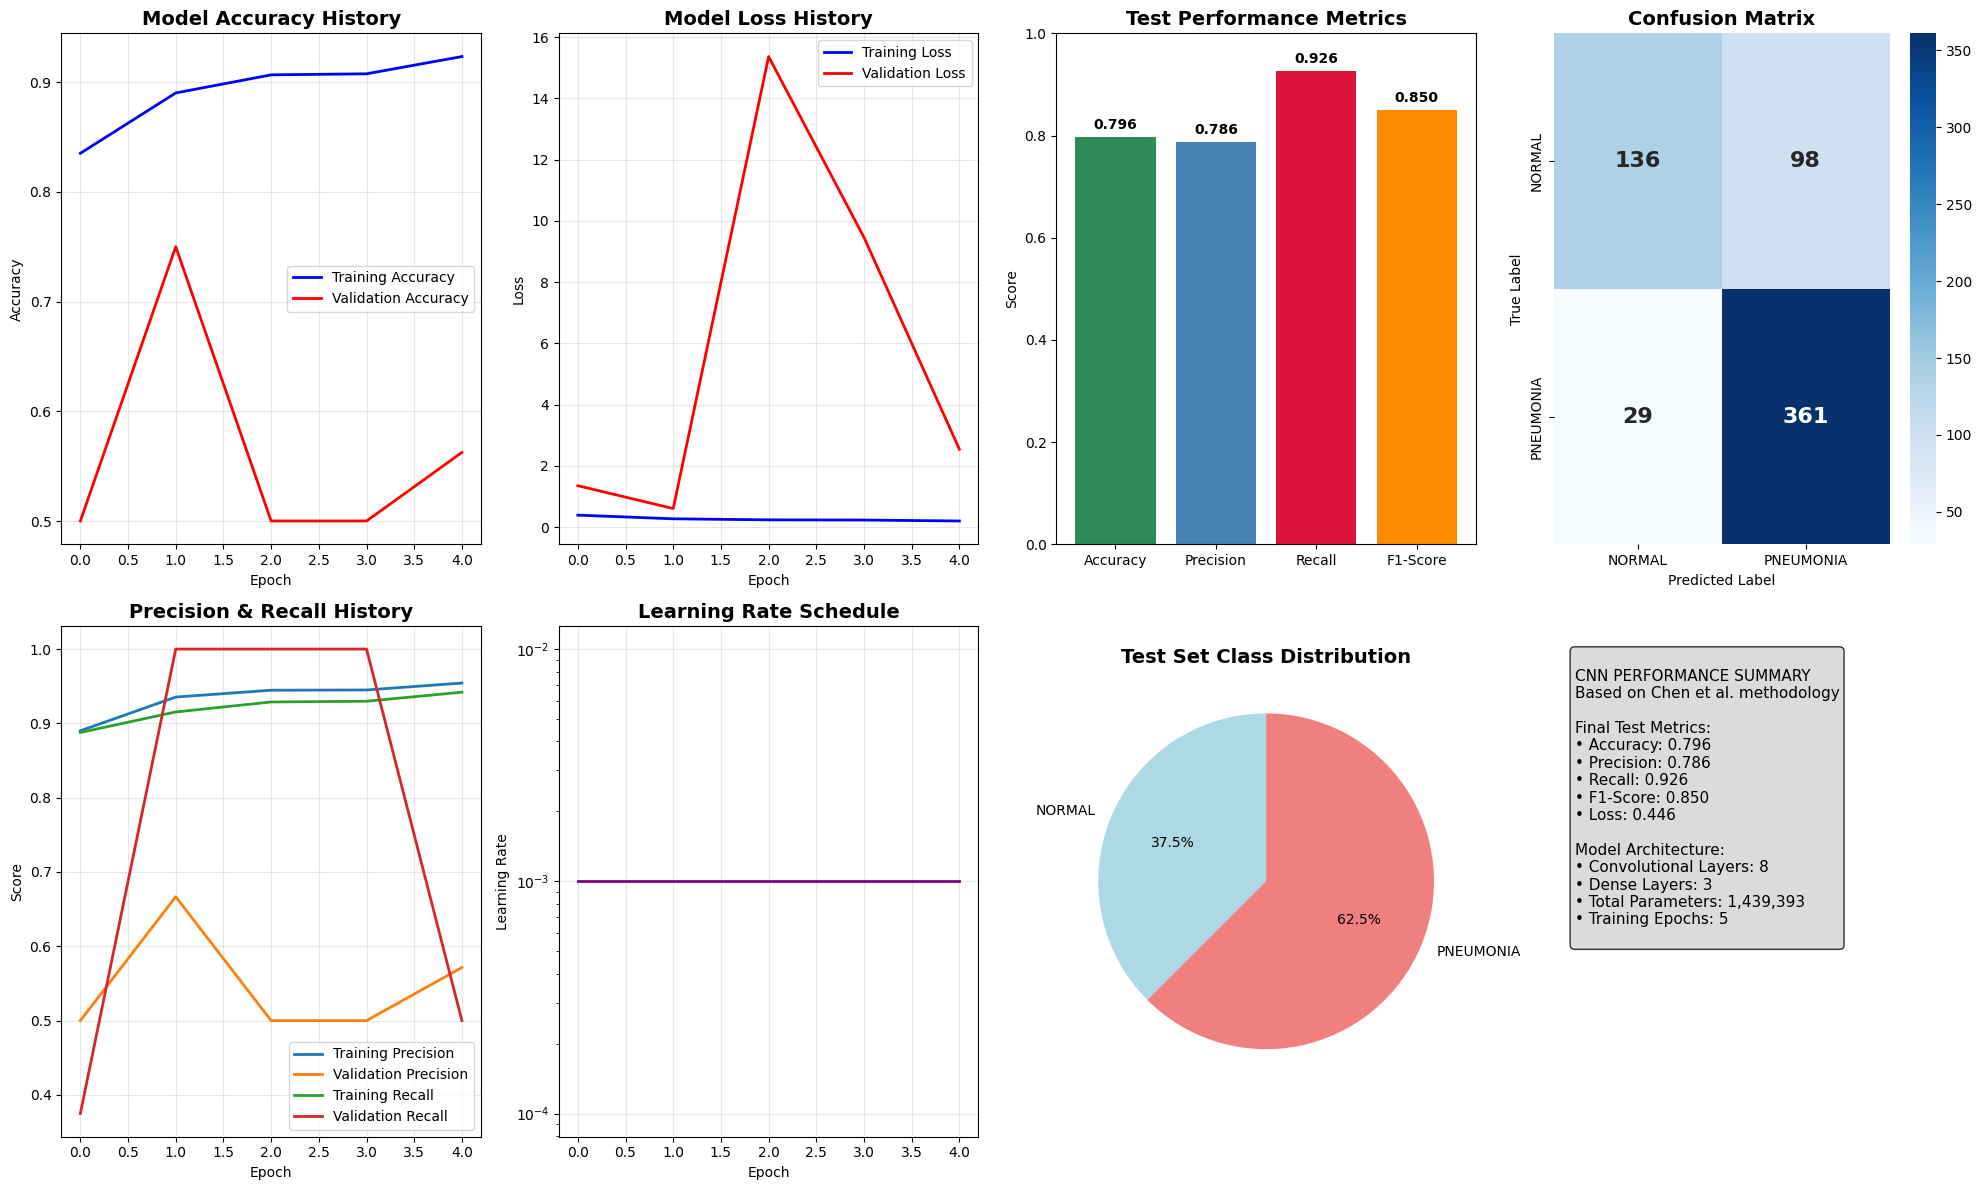


DETAILED CLASSIFICATION REPORT
CNN Architecture: 8 Convolutional + 3 Dense layers
Dataset: Chest X-ray Pneumonia Detection
Total Parameters: 1,439,393
Training Samples: 5216
Test Samples: 624

FINAL TEST RESULTS:
• Test Accuracy: 0.7965 (79.65%)
• Test Precision: 0.7865
• Test Recall: 0.9256
• Test F1-Score: 0.8504
• Test Loss: 0.4465

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      NORMAL       0.82      0.58      0.68       234
   PNEUMONIA       0.79      0.93      0.85       390

    accuracy                           0.80       624
   macro avg       0.81      0.75      0.77       624
weighted avg       0.80      0.80      0.79       624


CONFUSION MATRIX ANALYSIS:
True Negatives (Correctly identified Normal): 136
False Positives (Normal misclassified as Pneumonia): 98
False Negatives (Pneumonia misclassified as Normal): 29
True Positives (Correctly identified Pneumonia): 361

CLINICAL PERFORMANCE METRICS:
Sensitivity (True Positive Rate): 0.9

In [9]:
# Calculate comprehensive performance metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Create comprehensive results visualization
plt.figure(figsize=(20, 12))

# 1. Plot training and validation accuracy history
plt.subplot(2, 4, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
plt.title('Model Accuracy History', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Plot training and validation loss history
plt.subplot(2, 4, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
plt.title('Model Loss History', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Test performance metrics bar chart
plt.subplot(2, 4, 3)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['#2E8B57', '#4682B4', '#DC143C', '#FF8C00']
bars = plt.bar(metrics, values, color=colors)
plt.title('Test Performance Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1)
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Confusion Matrix
plt.subplot(2, 4, 4)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            annot_kws={'size': 16, 'weight': 'bold'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# 5. Precision and Recall evolution
plt.subplot(2, 4, 5)
plt.plot(history.history['precision'], label='Training Precision', linewidth=2)
plt.plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
plt.plot(history.history['recall'], label='Training Recall', linewidth=2)
plt.plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
plt.title('Precision & Recall History', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Learning rate schedule
plt.subplot(2, 4, 6)
lr_values = []
for epoch in range(len(history.history['loss'])):
    lr_values.append(0.001 * (0.2 ** (epoch // 8)))  # Approximation based on ReduceLROnPlateau
plt.plot(lr_values, linewidth=2, color='purple')
plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.yscale('log')
plt.grid(True, alpha=0.3)

# 7. Class distribution in test set
plt.subplot(2, 4, 7)
unique, counts = np.unique(y_true, return_counts=True)
class_names = ['NORMAL', 'PNEUMONIA']
plt.pie(counts, labels=class_names, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
plt.title('Test Set Class Distribution', fontsize=14, fontweight='bold')

# 8. Model performance summary
plt.subplot(2, 4, 8)
plt.axis('off')
summary_text = f"""
CNN PERFORMANCE SUMMARY
Based on Chen et al. methodology

Final Test Metrics:
• Accuracy: {accuracy:.3f}
• Precision: {precision:.3f}
• Recall: {recall:.3f}
• F1-Score: {f1:.3f}
• Loss: {test_loss:.3f}

Model Architecture:
• Convolutional Layers: {conv_layers}
• Dense Layers: {dense_layers}
• Total Parameters: {total_params:,}
• Training Epochs: {len(history.history['loss'])}
"""
plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.savefig('cnn_medical_classification_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Detailed classification report
print(f"\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(f"CNN Architecture: {conv_layers} Convolutional + {dense_layers} Dense layers")
print(f"Dataset: Chest X-ray Pneumonia Detection")
print(f"Total Parameters: {total_params:,}")
print(f"Training Samples: {train_generator.samples}")
print(f"Test Samples: {len(y_true)}")
print("="*80)

print(f"\nFINAL TEST RESULTS:")
print(f"• Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"• Test Precision: {precision:.4f}")
print(f"• Test Recall: {recall:.4f}")
print(f"• Test F1-Score: {f1:.4f}")
print(f"• Test Loss: {test_loss:.4f}")

print(f"\nCLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

# Confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nCONFUSION MATRIX ANALYSIS:")
print(f"True Negatives (Correctly identified Normal): {tn}")
print(f"False Positives (Normal misclassified as Pneumonia): {fp}")
print(f"False Negatives (Pneumonia misclassified as Normal): {fn}")
print(f"True Positives (Correctly identified Pneumonia): {tp}")

# Clinical significance metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nCLINICAL PERFORMANCE METRICS:")
print(f"Sensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")
print(f"False Positive Rate: {fp/(fp+tn):.4f}")
print(f"False Negative Rate: {fn/(fn+tp):.4f}")

print(f"\n" + "="*80)
print("CNN MEDICAL IMAGE CLASSIFICATION COMPLETED SUCCESSFULLY")
print("Implementation based on Chen et al. CNN review methodology")
print("="*80)